### Задача

1. Смоделируйте данные о расходах 1000 клиентов за месяц по трём категориям:

* Продукты: среднее 20 000 руб., σ = 5000.

* Развлечения: среднее 10 000 руб., σ = 4000.

* Онлайн-покупки: среднее 15 000 руб., σ = 7000.

2. Используя NumPy:

* создайте матрицу 1000×3, где строки — клиенты, а столбцы — категории расходов;

* найдите общие расходы каждого клиента (сумма по строкам);

* посчитайте корреляцию между категориями расходов (np.corrcoef).

3. Дополнительно:

* выделите топ-5% клиентов по общим расходам,

* посчитайте, какой процент общих расходов банка они формируют.

4. Визуализация:

* Постройте boxplot для трёх категорий,

* Постройте scatter plot «Продукты vs Онлайн-покупки» (каждая точка — клиент).

Общие расходы каждого клиента (первые 5 для примера):
[48354.74458658 46995.58253079 42930.02472318 47871.67146374
 33366.82371216]

Матрица корреляции между категориями:
[[ 1.         -0.04039987  0.02212886]
 [-0.04039987  1.         -0.01119938]
 [ 0.02212886 -0.01119938  1.        ]]

Топ-5% клиентов формируют 7.17% общих расходов банка


/var/folders/yq/64xbqr7d2js2pyzh65pxx9g00000gn/T/ipykernel_3392/2878979704.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(spending_matrix, labels=["Продукты", "Развлечения", "Онлайн-покупки"])


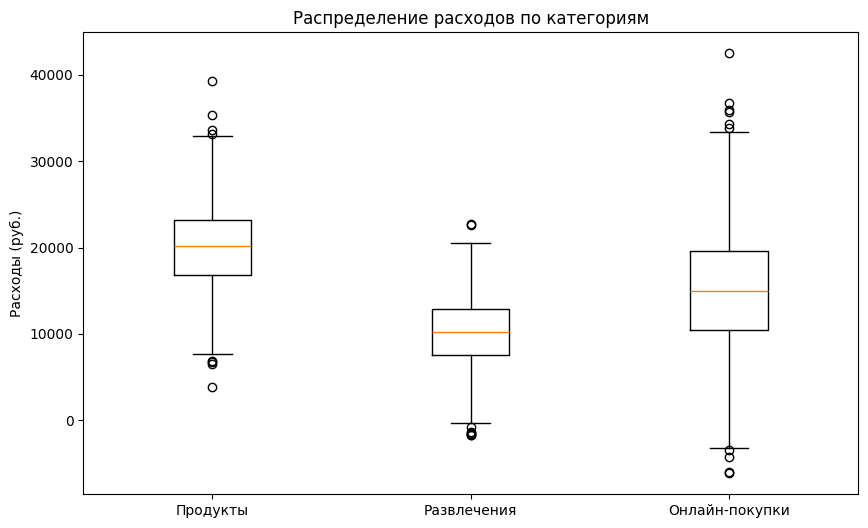

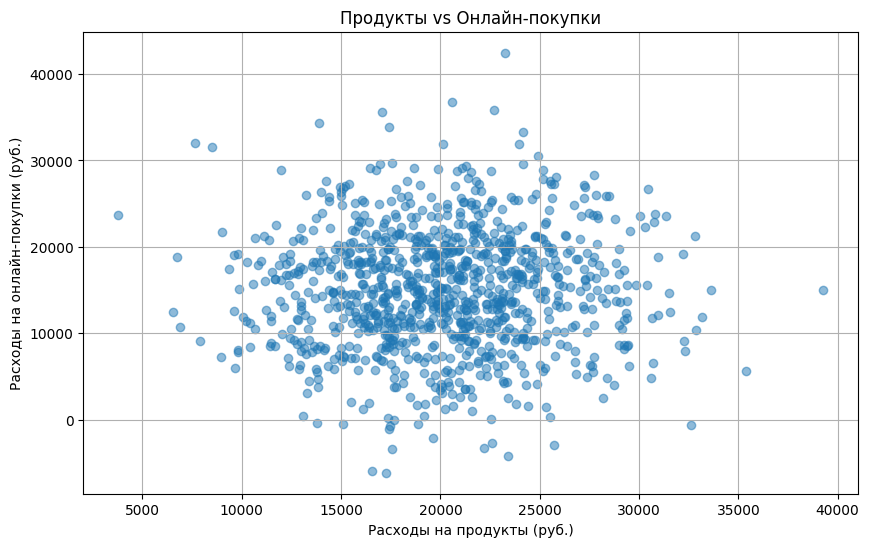

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Фиксируем зерно генератора для воспроизводимости
np.random.seed(42)

# ---------- СИМУЛЯЦИЯ ----------
# Генерация данных о расходах 1000 клиентов
groceries = np.random.normal(20000, 5000, 1000)
entertainment = np.random.normal(10000, 4000, 1000)
online = np.random.normal(15000, 7000, 1000)

# Создаем матрицу 1000x3
spending_matrix = np.column_stack((groceries, entertainment, online))

# ---------- АНАЛИЗ ----------
# Общие расходы каждого клиента (сумма по строкам)
total_spending = np.sum(spending_matrix, axis=1)

# Корреляция между категориями
correlation_matrix = np.corrcoef(spending_matrix, rowvar=False)

# Топ-5% клиентов по общим расходам
top_5_percent_idx = np.argsort(total_spending)[-50:]  # 5% от 1000 = 50
top_5_percent_spending = total_spending[top_5_percent_idx]
total_bank_spending = np.sum(total_spending)
top_5_percent_share = (np.sum(top_5_percent_spending) / total_bank_spending) * 100

# Вывод результатов
print("Общие расходы каждого клиента (первые 5 для примера):")
print(total_spending[:5])
print("\nМатрица корреляции между категориями:")
print(correlation_matrix)
print(f"\nТоп-5% клиентов формируют {top_5_percent_share:.2f}% общих расходов банка")

# ---------- ВИЗУАЛИЗАЦИЯ ----------
# Boxplot для трех категорий
plt.figure(figsize=(10, 6))
plt.boxplot(spending_matrix, labels=["Продукты", "Развлечения", "Онлайн-покупки"])
plt.title("Распределение расходов по категориям")
plt.ylabel("Расходы (руб.)")
plt.show()

# Scatter plot: Продукты vs Онлайн-покупки
plt.figure(figsize=(10, 6))
plt.scatter(groceries, online, alpha=0.5)
plt.title("Продукты vs Онлайн-покупки")
plt.xlabel("Расходы на продукты (руб.)")
plt.ylabel("Расходы на онлайн-покупки (руб.)")
plt.grid(True)
plt.show()